# MetroTransit Fleet – Exploratory Data Analysis

## Objective

This notebook performs Exploratory Data Analysis (EDA) on the cleaned Bike Sharing dataset.

The analysis focuses on:
- Understanding bike demand patterns
- Studying distributions and skewness
- Detecting anomalies/outliers
- Finding correlations
- Understanding feature interactions
- Examining category/class distribution
- Identifying actionable insights for bike fleet rebalancing


## 1. Import Required Libraries

The following libraries are used for data handling, statistical analysis, visualization, and correlation analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Load the Cleaned Dataset

Load the cleaned Bike Sharing dataset provided for the project.

In [4]:
df = pd.read_csv("/content/cleaned_bike_sharing.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Dataset Shape and Columns

Check the number of rows, columns, and available features.

In [5]:
print("Rows and Columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Rows and Columns: (17379, 17)

Columns:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


## 3. Basic Dataset Understanding

Before performing EDA, check data types, missing values, duplicate rows, and descriptive statistics.

In [6]:
df.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


In [7]:
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### Define Variables for EDA

The following variables are used for numerical and categorical/time-based analysis.

`cnt` is the total number of bike rentals and is the main demand variable.

In [10]:
numeric_cols = [
    'temp', 'atemp', 'hum', 'windspeed',
    'casual', 'registered', 'cnt'
]

categorical_cols = [
    'season', 'yr', 'mnth', 'hr',
    'holiday', 'weekday', 'workingday', 'weathersit'
]

## 4. Distribution Analysis

Distribution plots help us understand how bike demand and important numerical variables are spread.

We mainly examine `cnt`, `casual`, `registered`, temperature, humidity, and windspeed.

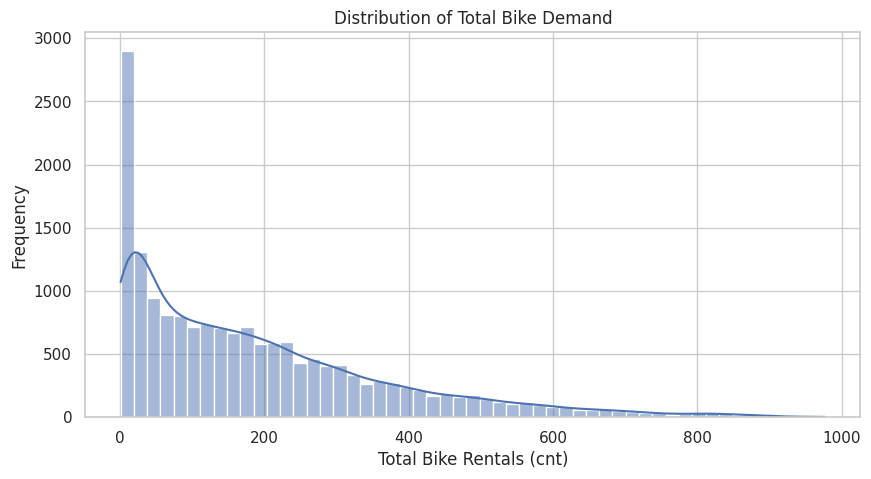

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='cnt', kde=True)
plt.title('Distribution of Total Bike Demand')
plt.xlabel('Total Bike Rentals (cnt)')
plt.ylabel('Frequency')
plt.show()

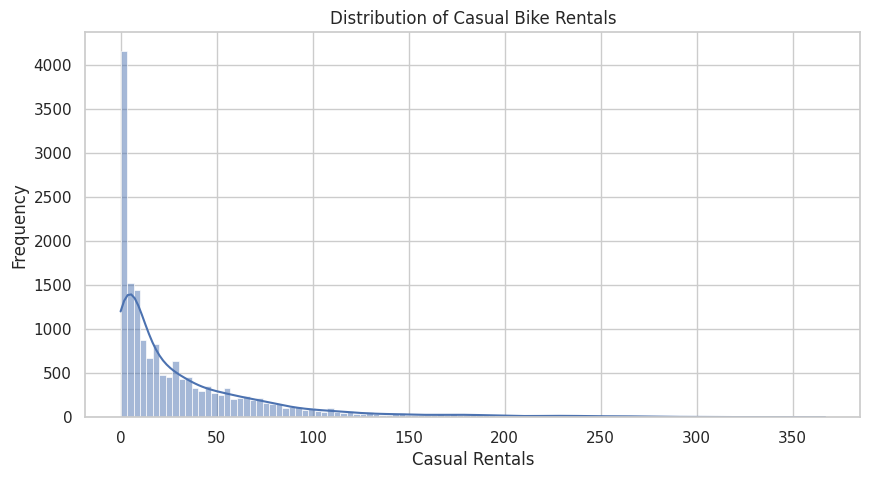

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='casual', kde=True)
plt.title('Distribution of Casual Bike Rentals')
plt.xlabel('Casual Rentals')
plt.ylabel('Frequency')
plt.show()

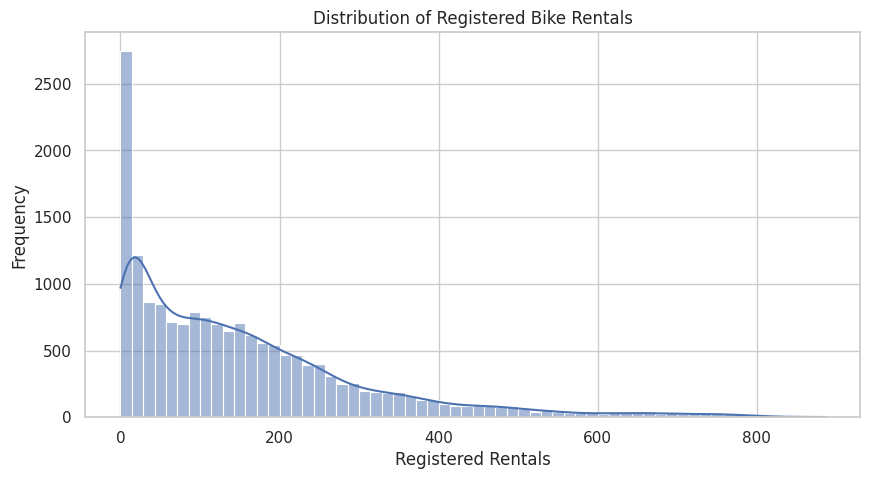

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='registered', kde=True)
plt.title('Distribution of Registered Bike Rentals')
plt.xlabel('Registered Rentals')
plt.ylabel('Frequency')
plt.show()

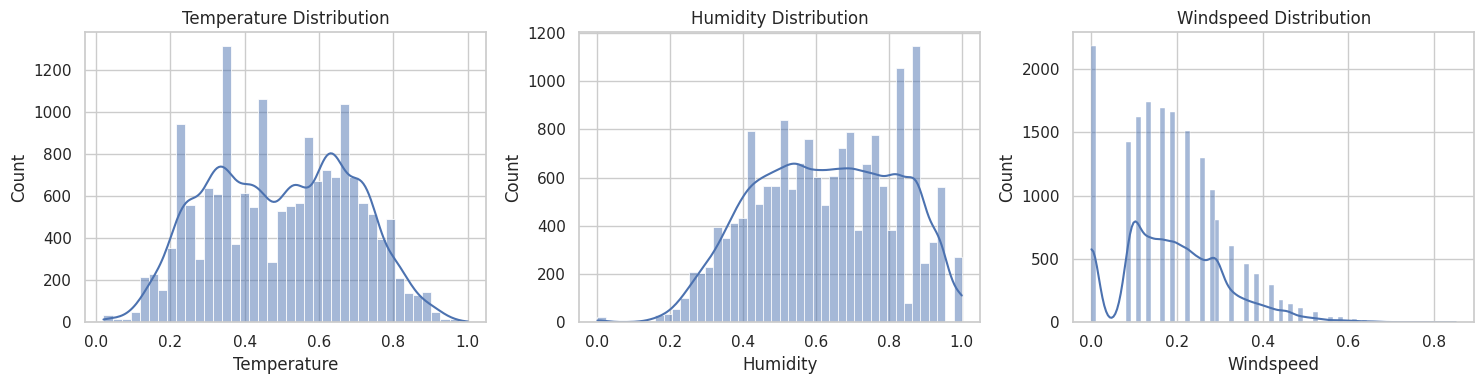

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(data=df, x='temp', kde=True, ax=axes[0])
axes[0].set_title('Temperature Distribution')
axes[0].set_xlabel('Temperature')

sns.histplot(data=df, x='hum', kde=True, ax=axes[1])
axes[1].set_title('Humidity Distribution')
axes[1].set_xlabel('Humidity')

sns.histplot(data=df, x='windspeed', kde=True, ax=axes[2])
axes[2].set_title('Windspeed Distribution')
axes[2].set_xlabel('Windspeed')

plt.tight_layout()
plt.show()

### Distribution Interpretation

Bike demand variables are generally right-skewed, meaning that many observations have relatively lower demand while a smaller number of observations have very high demand.

These high-demand observations should not automatically be removed because they may represent genuine peak-demand periods.

## 5. Skewness Analysis

Skewness measures the asymmetry of a distribution.

- Skewness > 0.5 → Right-skewed
- Skewness < -0.5 → Left-skewed
- Between -0.5 and 0.5 → Approximately symmetric

In [15]:
skewness = df[numeric_cols].skew().sort_values(ascending=False)
skewness

,0
casual,2.499237
registered,1.557904
cnt,1.277412
windspeed,0.574905
temp,-0.006021
atemp,-0.090429
hum,-0.111287


In [16]:
skewness_table = pd.DataFrame({
    'Feature': skewness.index,
    'Skewness': skewness.values
})

skewness_table['Interpretation'] = skewness_table['Skewness'].apply(
    lambda x: 'Right-skewed' if x > 0.5
    else ('Left-skewed' if x < -0.5 else 'Approximately symmetric')
)

skewness_table

,Feature,Skewness,Interpretation
0,casual,2.499237,Right-skewed
1,registered,1.557904,Right-skewed
2,cnt,1.277412,Right-skewed
3,windspeed,0.574905,Right-skewed
4,temp,-0.006021,Approximately symmetric
5,atemp,-0.090429,Approximately symmetric
6,hum,-0.111287,Approximately symmetric


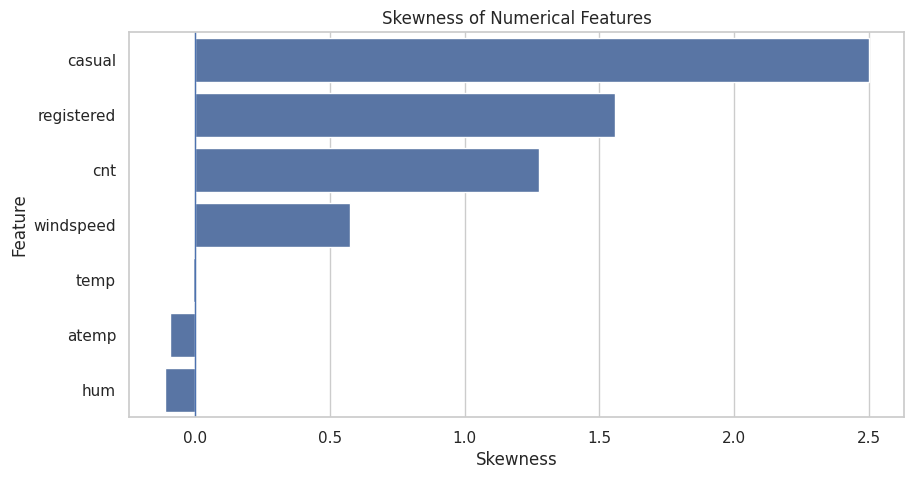

In [17]:
plt.figure(figsize=(10, 5))
sns.barplot(data=skewness_table, x='Skewness', y='Feature')
plt.axvline(0, linewidth=1)
plt.title('Skewness of Numerical Features')
plt.xlabel('Skewness')
plt.ylabel('Feature')
plt.show()

### Key Skewness Observation

`casual`, `registered`, and `cnt` show positive/right skewness. This indicates the presence of relatively high-demand observations.

Temperature, humidity, and windspeed are much closer to symmetric distributions.

## 6. Outlier and Anomaly Detection

Boxplots and the IQR method are used to identify unusual observations.

**Important:** An outlier is not automatically an error. In bike-sharing data, unusually high demand may represent real peak periods.

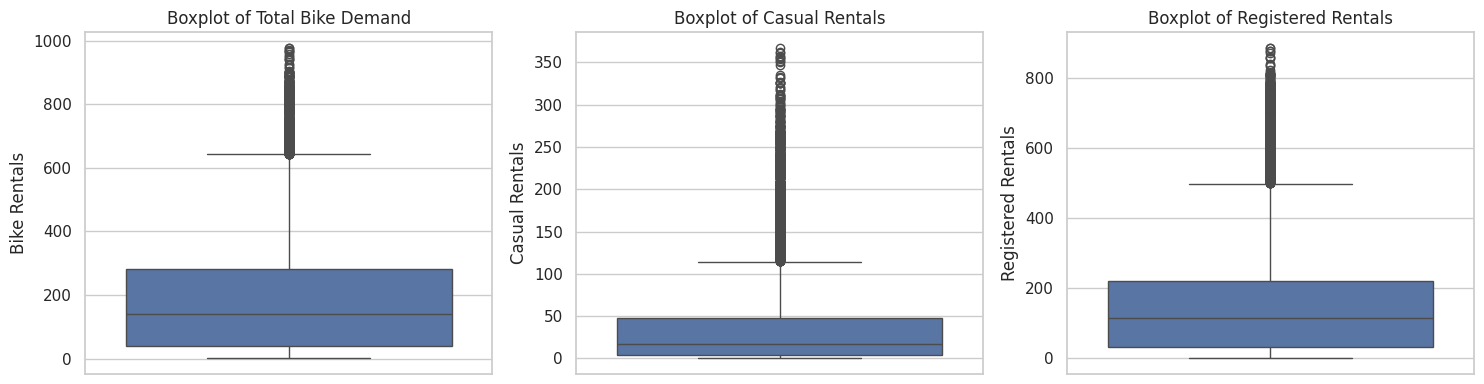

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, y='cnt', ax=axes[0])
axes[0].set_title('Boxplot of Total Bike Demand')
axes[0].set_ylabel('Bike Rentals')

sns.boxplot(data=df, y='casual', ax=axes[1])
axes[1].set_title('Boxplot of Casual Rentals')
axes[1].set_ylabel('Casual Rentals')

sns.boxplot(data=df, y='registered', ax=axes[2])
axes[2].set_title('Boxplot of Registered Rentals')
axes[2].set_ylabel('Registered Rentals')

plt.tight_layout()
plt.show()

In [19]:
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append([
        col, lower, upper, len(outliers)
    ])

outlier_table = pd.DataFrame(
    outlier_summary,
    columns=['Feature', 'Lower Bound', 'Upper Bound', 'Outlier Count']
)

outlier_table

,Feature,Lower Bound,Upper Bound,Outlier Count
0,temp,-0.14000,1.14000,0
1,atemp,-0.09855,1.05305,0
2,hum,0.03000,1.23000,22
3,windspeed,-0.11930,0.47750,342
4,casual,-62.00000,114.00000,1192
5,registered,-245.00000,499.00000,680
6,cnt,-321.50000,642.50000,505


## 7. Temporal Demand Analysis

Bike demand can change substantially depending on the time of day, season, and whether the day is a working day.

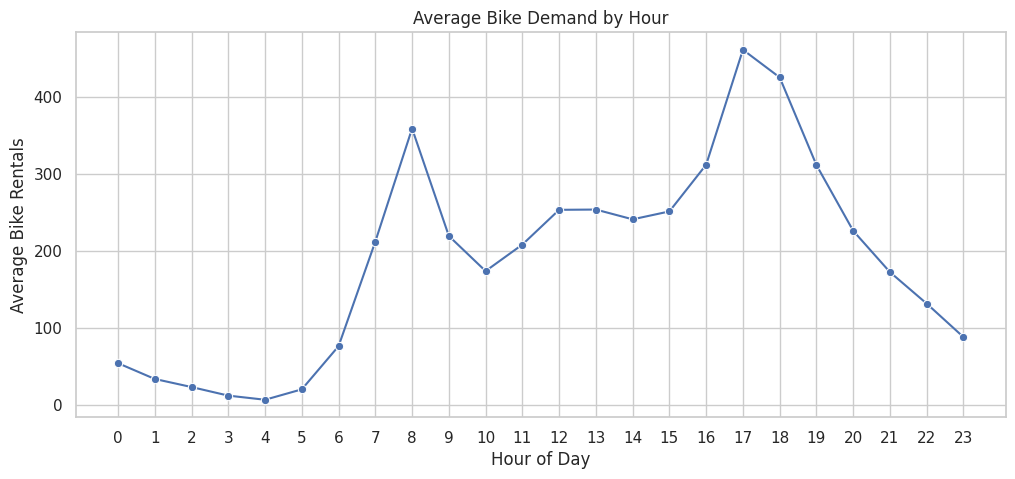

In [20]:
hourly_demand = df.groupby('hr')['cnt'].mean()

plt.figure(figsize=(12, 5))
sns.lineplot(
    x=hourly_demand.index,
    y=hourly_demand.values,
    marker='o'
)
plt.title('Average Bike Demand by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Bike Rentals')
plt.xticks(range(0, 24))
plt.show()

### Hourly Demand Interpretation

Demand is not uniform throughout the day. The dataset shows strong differences between low-demand and high-demand hours.

The highest average demand occurs around **17:00**, while the lowest occurs around **04:00**.

This is useful for planning fleet availability and rebalancing.

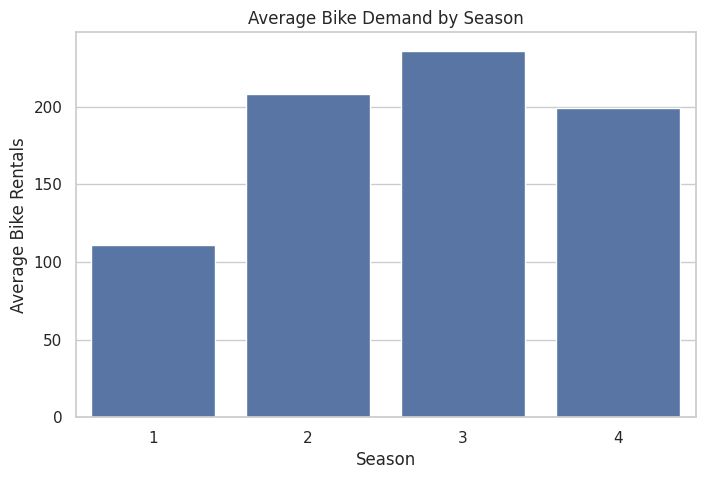

In [21]:
season_demand = df.groupby('season')['cnt'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=season_demand.index, y=season_demand.values)
plt.title('Average Bike Demand by Season')
plt.xlabel('Season')
plt.ylabel('Average Bike Rentals')
plt.show()

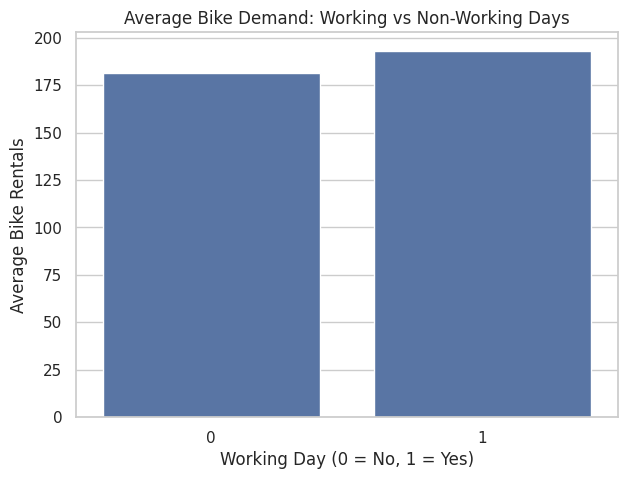

In [22]:
workingday_demand = df.groupby('workingday')['cnt'].mean()

plt.figure(figsize=(7, 5))
sns.barplot(x=workingday_demand.index, y=workingday_demand.values)
plt.title('Average Bike Demand: Working vs Non-Working Days')
plt.xlabel('Working Day (0 = No, 1 = Yes)')
plt.ylabel('Average Bike Rentals')
plt.show()

## 8. Correlation Analysis

Correlation measures the strength and direction of association between numerical variables.

- Positive correlation → variables tend to increase together
- Negative correlation → one tends to increase as the other decreases
- Correlation does **not** prove causation

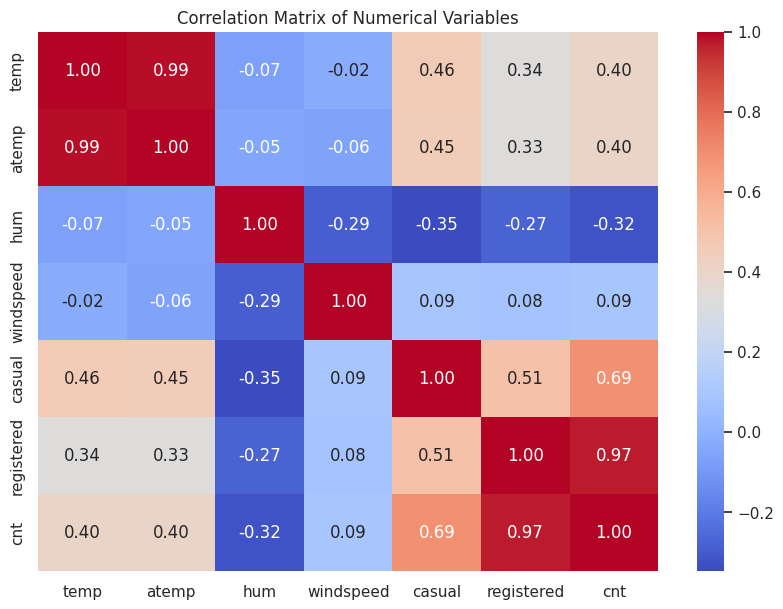

In [23]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

### Correlation with Bike Demand

The next analysis specifically examines how each numerical feature is associated with total bike demand (`cnt`).

In [24]:
target_corr = (
    df[numeric_cols]
    .corr()['cnt']
    .drop('cnt')
    .sort_values(key=abs, ascending=False)
)

target_corr

,cnt
registered,0.972151
casual,0.694564
temp,0.404772
atemp,0.400929
hum,-0.322911
windspeed,0.093234


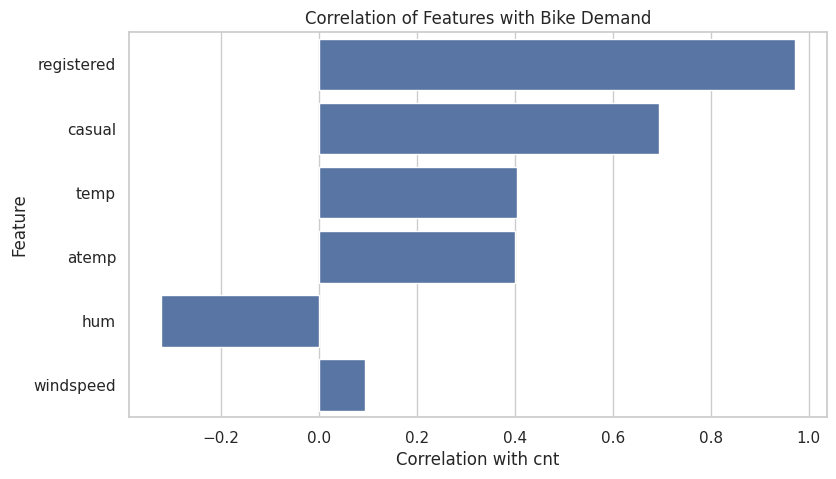

In [25]:
plt.figure(figsize=(9, 5))
sns.barplot(x=target_corr.values, y=target_corr.index)
plt.title('Correlation of Features with Bike Demand')
plt.xlabel('Correlation with cnt')
plt.ylabel('Feature')
plt.show()

### Correlation Interpretation

Important relationships with total demand include:

- `registered` has a very strong positive association with `cnt`.
- `casual` has a strong positive association with `cnt`.
- `temp` has a moderate positive association with `cnt`.
- `hum` has a negative association with `cnt`.
- `weathersit` has a negative association with `cnt`.

These are associations in the observed dataset and should not be interpreted as proof of causation.

## 9. Feature Interaction Analysis

Feature interactions help us understand whether the effect of one variable changes depending on another variable.

We examine:
1. Temperature and demand
2. Hour and working-day status
3. Weather and demand

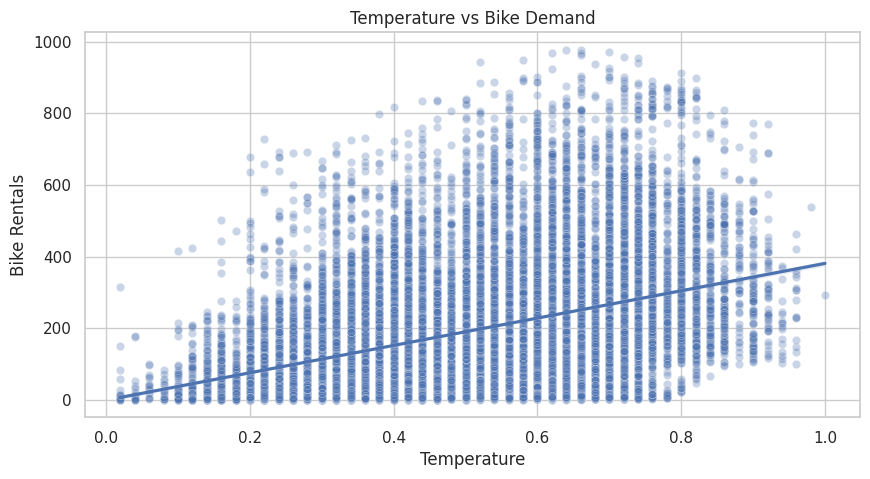

In [26]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x='temp',
    y='cnt',
    alpha=0.3
)

sns.regplot(
    data=df,
    x='temp',
    y='cnt',
    scatter=False
)

plt.title('Temperature vs Bike Demand')
plt.xlabel('Temperature')
plt.ylabel('Bike Rentals')
plt.show()

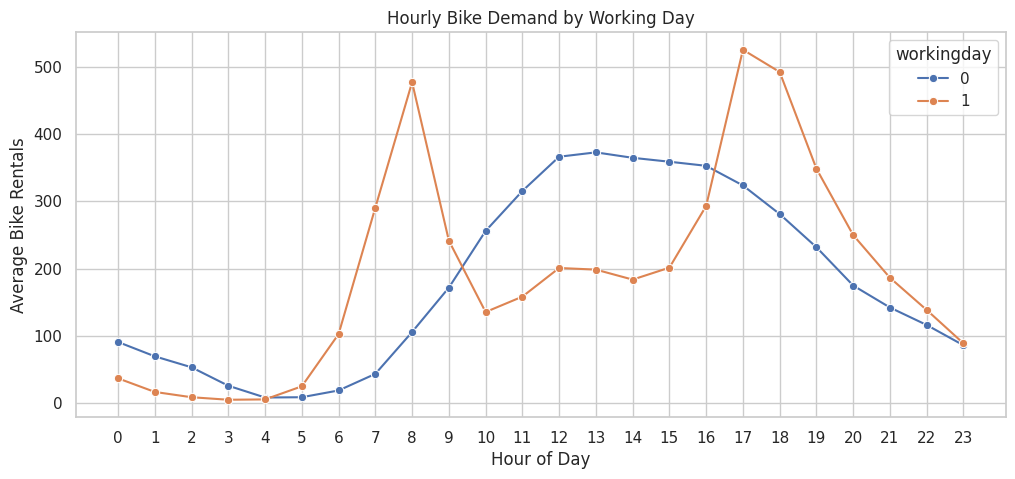

In [27]:
hour_working = (
    df.groupby(['hr', 'workingday'])['cnt']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hour_working,
    x='hr',
    y='cnt',
    hue='workingday',
    marker='o'
)

plt.title('Hourly Bike Demand by Working Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Bike Rentals')
plt.xticks(range(0, 24))
plt.show()

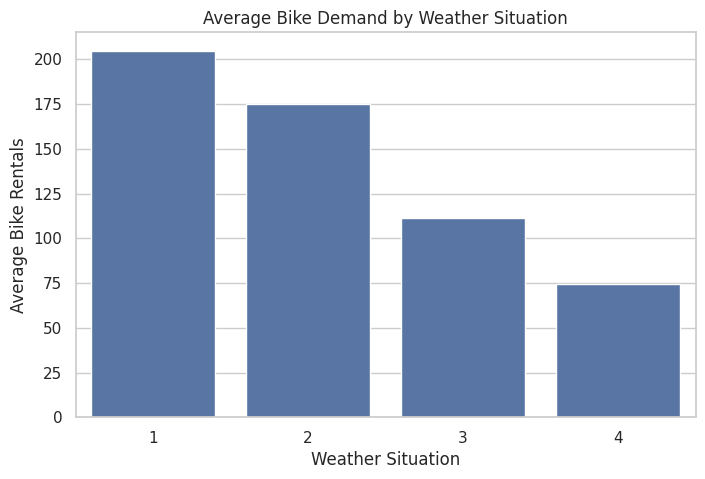

In [28]:
weather_demand = df.groupby('weathersit')['cnt'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=weather_demand.index, y=weather_demand.values)
plt.title('Average Bike Demand by Weather Situation')
plt.xlabel('Weather Situation')
plt.ylabel('Average Bike Rentals')
plt.show()

### Feature Interaction Interpretation

The relationship between time of day and demand differs by working-day status. This indicates that fleet planning should consider both the hour and the type of day rather than relying on one fixed hourly pattern.

Temperature also shows a positive association with demand, although the observations are spread across the range.

Weather categories show clear differences in average demand.

## 10. Class / Category Distribution Impact

`weathersit` is used as the main categorical variable for distribution analysis.

Checking its distribution is important because highly imbalanced categories can make comparisons involving rare categories less reliable.

In [29]:
weather_counts = df['weathersit'].value_counts().sort_index()
weather_counts

,count
weathersit,
1,11413
2,4544
3,1419
4,3


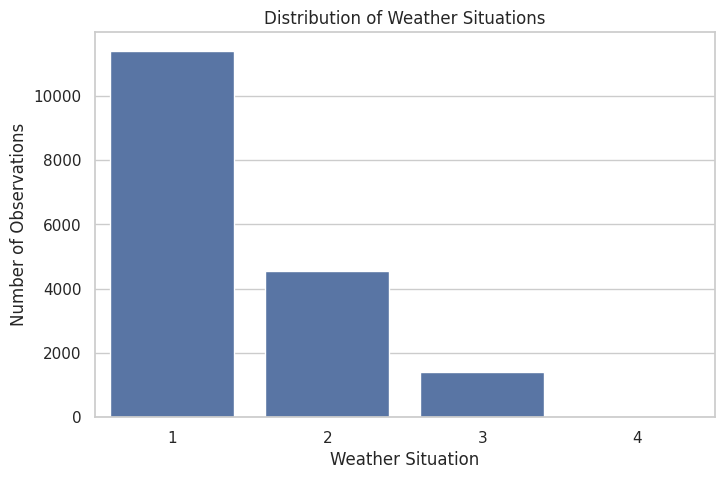

In [30]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='weathersit')

plt.title('Distribution of Weather Situations')
plt.xlabel('Weather Situation')
plt.ylabel('Number of Observations')
plt.show()

In [31]:
weather_percentage = (
    df['weathersit']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

weather_percentage

,proportion
weathersit,
1,65.671212
2,26.146499
3,8.165027
4,0.017262


### Class Distribution Interpretation

The weather categories are highly imbalanced.

Most observations belong to the clearer weather category, while severe weather observations are extremely rare.

Therefore, average demand for rare weather categories should be interpreted cautiously because they are based on much fewer observations.

## 11. Statistical EDA – Working vs Non-Working Days

An independent samples t-test is used to examine whether the average bike demand differs between working and non-working days.

A p-value below 0.05 is commonly used as evidence of a statistically significant difference.

In [32]:
working = df[df['workingday'] == 1]['cnt']
non_working = df[df['workingday'] == 0]['cnt']

t_stat, p_value = stats.ttest_ind(
    working,
    non_working,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 4.095067721524371
P-value: 4.249478377549554e-05


In [33]:
if p_value < 0.05:
    print("The difference in average demand between working and non-working days is statistically significant.")
else:
    print("The difference in average demand between working and non-working days is not statistically significant.")

The difference in average demand between working and non-working days is statistically significant.


## 12. Top 3 Actionable Data Insights

### Insight 1 – Demand varies strongly by hour
Average demand changes substantially across the 24-hour period. Fleet availability and rebalancing can therefore be planned around high-demand hours.

### Insight 2 – Weather is associated with demand
Average demand decreases across poorer weather situations. Weather information can therefore be considered when planning fleet availability and rebalancing.

### Insight 3 – Hour and working-day status interact
Hourly demand patterns differ between working and non-working days. Fleet allocation should therefore consider both time of day and day type rather than using one fixed schedule.

These insights describe patterns observed in the dataset and are intended to support operational planning.

## 13. Final EDA Summary

The EDA shows that:

- Bike demand is positively skewed, with some high-demand observations.
- High-demand observations should not automatically be treated as errors.
- Demand varies strongly by hour and season.
- Temperature has a positive association with total demand.
- Humidity and poorer weather conditions are associated with lower demand.
- Weather categories are highly imbalanced, especially the rare severe-weather category.
- Hour and working-day status show an important interaction.
- These patterns can support fleet rebalancing and demand-management decisions.
